In [50]:
 %pylab inline
import torch 
import torch.nn as nn 
import torch.nn.functional as F
import torchvision
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from keras.datasets import mnist
import numpy as np
from tqdm import trange

Populating the interactive namespace from numpy and matplotlib


In [2]:
# Load Data 
(x_train, _), (_, _) = mnist.load_data()

In [27]:
# GAN Models 

# Number of neurons 
image_size = 784 
h_dim = 128 
z_dim = 100


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.L1 = nn.Linear(image_size, h_dim)
        self.L2 = nn.Linear(h_dim, 1)
    
    def forward(self, x):
        x = F.relu(self.L1(x))
        x = F.sigmoid(self.L2(x))
        return x 

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.L1 = nn.Linear(z_dim, h_dim)
        self.L2 = nn.Linear(h_dim, image_size)
    
    def forward(self, x):
        x = F.relu(self.L1(x))
        x = F.sigmoid(self.L2(x))
        return x 



In [28]:
# Models 
g = Generator().to(device)
d = Discriminator().to(device)
# Loss and Optimizations 
loss_function = nn.BCELoss()
g_optim = torch.optim.Adam(g.parameters())
d_optim = torch.optim.Adam(d.parameters())
 


 31%|███       | 62/200 [00:00<00:00, 298.74it/s]d_loss 0.020, g_loss = 4.216
d_loss 0.036, g_loss = 4.261
 62%|██████▏   | 124/200 [00:00<00:00, 304.19it/s]d_loss 0.045, g_loss = 3.357
d_loss 0.358, g_loss = 1.582
100%|██████████| 200/200 [00:00<00:00, 307.83it/s]d_loss 0.011, g_loss = 4.531



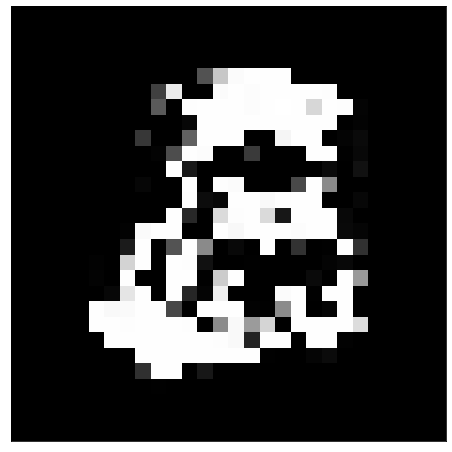

In [58]:
# Plot images 
def imshow(imgs):
    imgs = torchvision.utils.make_grid(imgs.view(28, 28).cpu().detach())
    npimgs = imgs.numpy()
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(npimgs, (1,2,0)), cmap='Greys_r')
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Convenient HyperParam Placemnt 
epochs = 200
batch_size = 64 
steps = epochs // 5 

# Training Loop 
for epoch in trange(epochs):
    rand_batch = np.random.randint(0, x_train.shape[0], size=batch_size)
    # Data 
    x_real = torch.tensor(x_train[rand_batch].reshape(-1, 784)).float().to(device)
    y_real = torch.ones(batch_size, 1).to(device)
    x_fake = torch.randn(batch_size, z_dim).to(device)
    y_fake = torch.zeros(batch_size, 1).to(device)

    # Real Training 
    d_real = d(x_real)
    real_loss = loss_function(d_real, y_real)

    # Fake Training 
    d_fake = d(g(x_fake))
    fake_loss = loss_function(d_fake, y_fake)

    # Update Weights     
    d_loss = fake_loss + real_loss
    d_optim.zero_grad()
    d_loss.backward()
    d_optim.step()
 
    #============
    # Generator
    #============
    # G Training
    x_fake = torch.randn(batch_size, z_dim).to(device)
    d_fake = d(g(x_fake))
    g_loss = loss_function(d_fake, y_real)

    # Updating Weights 
    g_optim.zero_grad()
    g_loss.backward()
    g_optim.step()
    if epoch % steps == 0:
        print(f"d_loss {d_loss.item():.3f}, g_loss = {g_loss.item():.3f}")

g_images = g(x_fake)
imshow(g_images[4]) 
